# Deep Learning

This module shows an example of using a Neural Network to create a predictive model for mortality. The following is the basis for neural network algorithm.

$$\underbrace{\hat{y}}_{\text{Output}} =
\underbrace{g}_{\text{Non-linear activation function}}
\!\left(
\underbrace{w_0}_{\text{Bias}} +
\underbrace{\sum_{i=1}^{m} x_i w_i}_{\text{Linear combination of inputs}}
\right)
$$

There are several types of neural networks and a few listed below. The general process is that there is an input, which has a set of weights and a bias term, that then goes through an activation function (e.g. sigmoid, relu, softmax), which will be the neuron. These then have a loss function that is optimizing the loss. The matrix can be configured depending how deep (number of layers) and wide (number of neurons) the network should be.

- **Feed Forward Neural Network (FFNN)** - This is the simplest type of neural network. 
- **Recurrent Neural Network (RNN)** - Main use is for sequential data. They allow the output of one step to be fed as input into the next step. Some drawbacks of RNN are bottleneck embedding which can be addressed using transformers, no parallelization, no long term memory due to vanishing gradients because the losses are added together for an entire sequence.
- **Convolutional Neural Network (CNN)** - Main use is for image classification, which uses "filters" to identify small important features of a picture which would be used together to form larger interconnected features to classify an image. One caveat is that what the model trains on is what it will expect. For instance, if model only had upright heads in training data, it wouldn't be able to identify a sideways head.

There are some regularlization that can happen as well:
- **Dropout** - removes a percent of activation layers
- **Early Stopping** - stop training before overfitting

If wanting to learn more on neural networks, the following course was helpful:
- https://introtodeeplearning.com/

# Import Modules

In [1]:
import importlib
import os
import sys

import joblib
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

In [2]:
os.chdir("../")
sys.path.insert(0, os.getcwd())

In [3]:
from morai.experience import charters, experience, tables
from morai.forecast import metrics, preprocessors
from morai.models import neural
from morai.utils import custom_logger, helpers

In [4]:
logger = custom_logger.setup_logging(__name__)

In [5]:
# update log level if wanting more logging
custom_logger.set_log_level("INFO")

In [6]:
pd.options.display.float_format = "{:,.2f}".format

In [7]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

**This `Data` section only needs to be run once.** If the file `mortality_grouped.parquet` is in the datasets folder, then can skip to step 4. Neural

## Load Data

Partition data is much faster to load and work with in parquet format, so saving for future use.

In [ ]:
csv_file = r"C:\Users\johnk\Desktop\nextcloud\actuarial\SOA\datasets\ILEC_2012_19 - 20240429.txt"
write_path = r"files\partition"

In [ ]:
pl_dtypes = {
    "Observation_Year": pl.Int32,
    "Age_Ind": pl.Categorical,
    "Sex": pl.Categorical,
    "Smoker_Status": pl.Categorical,
    "Insurance_Plan": pl.Categorical,
    "Issue_Age": pl.Int32,
    "Duration": pl.Int32,
    "Face_Amount_Band": pl.Categorical,
    "Issue_Year": pl.Int32,
    "Attained_Age": pl.Int32,
    "SOA_Antp_Lvl_TP": pl.Categorical,
    "SOA_Guar_Lvl_TP": pl.Categorical,
    "SOA_Post_Lvl_Ind": pl.Categorical,
    "Slct_Ult_Ind": pl.Categorical,
    "Preferred_Class": pl.Categorical,
    "Number_of_Pfd_Classes": pl.Categorical,
    "Preferred_Indicator": pl.Categorical,
    "MIB_Flag": pl.Categorical,
    "Amount_Exposed": pl.Float64,
    "Policies_Exposed": pl.Float64,
    "Death_Claim_Amount": pl.Int64,
    "Death_Count": pl.Int64,
    "ExpDth_Amt_VBT2015": pl.Float64,
    "ExpDth_Amt_VBT2015wMI": pl.Float64,
    "ExpDth_Cnt_VBT2015": pl.Float64,
    "ExpDth_Cnt_VBT2015wMI": pl.Float64,
    "Cen2MomP1wMI_byAmt": pl.Float64,
    "Cen2MomP2wMI_byAmt": pl.Float64,
    "Cen3MomP1wMI_byAmt": pl.Float64,
    "Cen3MomP2wMI_byAmt": pl.Float64,
    "Cen3MomP3wMI_byAmt": pl.Float64,
}

In [ ]:
lzdf = pl.read_csv(
    csv_file,
    separator="\t",
    schema_overrides=pl_dtypes,
)

In [ ]:
# 5 minute
lzdf.write_parquet(
    write_path,
    compression="snappy",
    use_pyarrow=True,
    pyarrow_options={"partition_cols": ["Observation_Year", "Sex"]},
)

## Read Data

In [85]:
# needs asterisks to load in all folders and files
pl_hive_path = r"files\partition\*\*\*.parquet"

In [86]:
variables = [
    "Observation_Year",
    "Sex",
    "Smoker_Status",
    "Insurance_Plan",
    "Issue_Age",
    "Duration",
    "Face_Amount_Band",
    "Issue_Year",
    "Attained_Age",
    "SOA_Post_Lvl_Ind",
    "Number_of_Pfd_Classes",
    "Preferred_Class",
]
measures = [
    "Amount_Exposed",
    "Policies_Exposed",
    "Death_Claim_Amount",
    "Death_Count",
]
columns_needed = variables + measures
columns_not_needed = [
    "SOA_Antp_Lvl_TP",
    "SOA_Guar_Lvl_TP",
    "MIB_Flag",
    "Preferred_Indicator",
    "Slct_Ult_Ind",
    "ExpDth_Amt_VBT2015",
    "ExpDth_Amt_VBT2015wMI",
    "ExpDth_Cnt_VBT2015",
    "ExpDth_Cnt_VBT2015wMI",
    "Cen2MomP1wMI_Amt",
    "Cen2MomP2wMI_Amt",
    "Cen3MomP1wMI_Amt",
    "Cen3MomP2wMI_Amt",
    "Cen3MomP3wMI_Amt",
    "Type_Underwriting_Requirements",
    "Substandard_Indicator",
]

In [87]:
# reading in the dataset
# `enable_string_cache` helps with categorical type values
pl.enable_string_cache()
lzdf = pl.scan_parquet(
    pl_hive_path,
    hive_partitioning=True,
)

In [88]:
initial_row_count = lzdf.select(pl.len()).collect().item()
print(
    f"row count: {initial_row_count:,} \n"
    f"exposures: {lzdf.select([pl.col('Amount_Exposed').sum()]).collect()[0,0]:,}"
)

row count: 45,501,036 
exposures: 105,573,155,815,950.17


### Filter Data

In [89]:
no_values = (
    (pl.col("Amount_Exposed") != 0)
    | (pl.col("Policies_Exposed") != 0)
    | (pl.col("Death_Claim_Amount") != 0)
    | (pl.col("Death_Count") != 0)
)

In [90]:
no_values_row_count = lzdf.filter(no_values).select(pl.len()).collect().item()
print(f"removing {initial_row_count-no_values_row_count:,} cells")

removing 219,063 cells


In [91]:
no_exposure = pl.col("Amount_Exposed") <= 0

In [92]:
no_exposure_count = (
    lzdf.filter(no_values).filter(~no_exposure).select(pl.len()).collect().item()
)
print(f"removing {no_values_row_count-no_exposure_count:,} cells")

removing 702 cells


In [93]:
base_filters = (
    (pl.col("Issue_Age") >= 30)
    & (pl.col("Issue_Age") <= 80)
    & (pl.col("Attained_Age") >= 50)
    & (pl.col("Attained_Age") <= 95)
    & (pl.col("SOA_Post_Lvl_Ind").is_in(["WLT", "N/A"]))
    & (pl.col("Insurance_Plan") != "Other")
    & (pl.col("Issue_Year") >= 1980)
    & (pl.col("Smoker_Status") != "U")
)

In [94]:
base_filters_count = (
    lzdf.filter(no_values)
    .filter(~no_exposure)
    .filter(~base_filters)
    .select(pl.len())
    .collect()
    .item()
)
print(f"removing {no_exposure_count-base_filters_count:,} cells")

removing 18,495,707 cells


In [96]:
grouped_df = (
    lzdf.group_by(variables)
    .agg([pl.col(measure).sum() for measure in measures])
    .filter(no_values)
    .filter(~no_exposure)
    .filter(base_filters)
    .collect()
)

In [97]:
grouped_df = grouped_df.to_pandas()

In [98]:
# sampling due to running on 16GB RAM CPU. If using a GPU or higher RAM the data would not need to be sampled.
# grouped_df = grouped_df.sample(frac=0.1, random_state=42)

### Clean Data

In [99]:
grouped_df = helpers.clean_df(grouped_df)

 2026-01-21 21:36:24 | morai.utils.helpers | INFO     | lowercasing the column names 
 2026-01-21 21:36:24 | morai.utils.helpers | INFO     | replacing special characters with underscores in the column names 
 2026-01-21 21:36:24 | morai.utils.helpers | INFO     | removed unused categories and reorder 
 2026-01-21 21:36:32 | morai.utils.helpers | INFO     | update index to int32 
 2026-01-21 21:36:32 | morai.utils.helpers | INFO     | dataFrame shape: (9386630, 16) 


In [100]:
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9386630 entries, 0 to 9386629
Data columns (total 16 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   observation_year       int64   
 1   sex                    object  
 2   smoker_status          category
 3   insurance_plan         category
 4   issue_age              int32   
 5   duration               int32   
 6   face_amount_band       category
 7   issue_year             int32   
 8   attained_age           int32   
 9   soa_post_lvl_ind       category
 10  number_of_pfd_classes  category
 11  preferred_class        category
 12  amount_exposed         float64 
 13  policies_exposed       float64 
 14  death_claim_amount     int64   
 15  death_count            int64   
dtypes: category(6), float64(2), int32(4), int64(3), object(1)
memory usage: 662.4+ MB


In [101]:
print(
    f"row count: {len(grouped_df):,} \n"
    f"exposures: {grouped_df['amount_exposed'].sum():,}"
)

row count: 9,386,630 
exposures: 40,714,555,047,710.36


### Calculated Fields

In [102]:
grouped_df["class_enh"] = (
    grouped_df["number_of_pfd_classes"].astype(str)
    + "_"
    + grouped_df["preferred_class"].astype(str)
).astype("category")

In [103]:
grouped_df["capped_duration"] = grouped_df["duration"].clip(upper=26)
binned_face_dict = {
    "01: 0 - 9,999": "01: 0 - 24,999",
    "02: 10,000 - 24,999": "01: 0 - 24,999",
    "03: 25,000 - 49,999": "02: 25,000 - 99,999",
    "04: 50,000 - 99,999": "02: 25,000 - 99,999",
    "05: 100,000 - 249,999": "03: 100,000 - 249,999",
    "06: 250,000 - 499,999": "04: 250,000 - 4,999,999",
    "07: 500,000 - 999,999": "04: 250,000 - 4,999,999",
    "08: 1,000,000 - 2,499,999": "04: 250,000 - 4,999,999",
    "09: 2,500,000 - 4,999,999": "04: 250,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999": "05: 5,000,000+",
    "11: 10,000,000+": "05: 5,000,000+",
}
grouped_df["binned_face"] = grouped_df["face_amount_band"].map(binned_face_dict)
grouped_df["binned_face"] = grouped_df["binned_face"].astype("category")

### Add qx

In [104]:
grouped_df = tables.map_rates(
    df=grouped_df,
    rate="vbt15",
)
grouped_df["exp_amt_vbt15"] = grouped_df["qx_vbt15"] * grouped_df["amount_exposed"]
grouped_df["ae_vbt15"] = np.where(
    grouped_df["amount_exposed"] == 0,
    0,
    grouped_df["death_claim_amount"] / grouped_df["exp_amt_vbt15"],
)

 2026-01-21 21:36:50 | morai.experience.tables | INFO     | mapping rate: 'qx_vbt15' with format: 'soa' 
 2026-01-21 21:37:00 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['issue_age', 'duration', 'sex', 'smoker_status'] 


In [105]:
grouped_df["qx_raw"] = np.where(
    grouped_df["amount_exposed"] == 0,
    0,
    grouped_df["death_claim_amount"] / grouped_df["amount_exposed"],
)
grouped_df["qx_raw"] = grouped_df["qx_raw"].clip(upper=1)

## Write Data

In [106]:
# categories saves on memory
for col in grouped_df.select_dtypes(include="object").columns:
    grouped_df[col] = grouped_df[col].astype("category")

In [107]:
# write to file for predictive model
grouped_df.to_parquet("files/dataset/full_mortality_grouped.parquet")

In [108]:
grouped_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9386630 entries, 0 to 9386629
Data columns (total 23 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   observation_year       int64   
 1   sex                    category
 2   smoker_status          category
 3   insurance_plan         category
 4   issue_age              int32   
 5   duration               int32   
 6   face_amount_band       category
 7   issue_year             int32   
 8   attained_age           int32   
 9   soa_post_lvl_ind       category
 10  number_of_pfd_classes  category
 11  preferred_class        category
 12  amount_exposed         float64 
 13  policies_exposed       float64 
 14  death_claim_amount     int64   
 15  death_count            int64   
 16  class_enh              category
 17  capped_duration        int32   
 18  binned_face            category
 19  qx_vbt15               float64 
 20  exp_amt_vbt15          float64 
 21  ae_vbt15               float64 

In [109]:
del grouped_df

# Neural

In [8]:
model_name = "neural"

## Data

Process the data by:

- **Encoding**
  - categorical variables need to be encoded using ordinal, nominal, ohe, embedding
 
- **Feature Engineering**
  - the attained age was split into splines so the neural network was given the structure and would not need to learn from scratch

- **Standardizing**
  - it's helpful for a neural network to have standarized fields to avoid a feature to have too much weight in gradient

- **Splitting**
  - have a test/train split for validation using 20% of the data for testing

In [9]:
pl_parquet_path = r"files/dataset/full_mortality_grouped.parquet"

In [10]:
model_data = pl.read_parquet(pl_parquet_path, use_pyarrow=True)

In [11]:
model_data = model_data.to_pandas()

In [12]:
feature_dict = {
    "target": ["qx_raw"],
    "weight": ["amount_exposed"],
    "passthrough": [
        "duration",
        "face_amount_band",
    ],
    "ordinal": [
        "sex",
        "smoker_status",
        "observation_year",
    ],
    "nominal": [],
    "ohe": [
        "class_enh",
        "insurance_plan",
    ],
    "spline": {
        "attained_age": {"n_knots": 8, "degree": 3, "knots": "quantile"},
    },
}

In [13]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=True,
)

 2026-01-22 03:13:32 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-01-22 03:13:32 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2026-01-22 03:13:32 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['duration', 'face_amount_band'] 
 2026-01-22 03:13:32 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['sex', 'observation_year', 'smoker_status'] 
 2026-01-22 03:13:38 | morai.forecast.preprocessors | INFO     | ohe - one hot encoded (dropping first col): ['class_enh', 'insurance_plan'] 
 2026-01-22 03:13:42 | morai.forecast.preprocessors | INFO     | spline - b-spline basis expansion: ['attained_age'] 
 2026-01-22 03:13:44 | morai.forecast.preprocessors | INFO     | standardizing the features with StandardScaler (that excludes OHE) 


In [14]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]
spline_dict = preprocess_dict["spline_dict"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

## Model

The model is set up with the following. It was chosen to use a wide and deep path to have the model learn quickly the mortality features with a wide path. This forms the "GLM" structure. The deep path then focuses on the more nuanced relationships.

- **architecture**
2 separate paths

  - Wide Path
    - **input layer:** (1 neuron)
  - Deep Path
    - **input layer:** (32 neurons) ReLU activation
    - **hidden layer 1:** (32 neurons) ReLU activation
    - **hidden layer 2:** (16 neurons) ReLU activation
    - **output** (1 neuron)
  - The prediction is then wide + deep.

- **learning rate**
  - learning rate is defined as parameter, but does decrease learning rate when loss plateaus
  - uses the Adam optimizer

- **loss**
  - either uses a poisson or binomial loss, instead of MSE, etc.

- **other features**
  - dropout can be defined
  - early stopping after 50 epochs of no improvement on training set
  - initialized to use overall mortality rate

In [15]:
model = neural.Neural(
    task="poisson",
    embedding_cols=[
        "face_amount_band",
    ],
)

 2026-01-22 03:14:04 | morai.models.neural | INFO     | initialized Neural model with Torch
task: poisson 
device: cuda 


## Embedding

Neural Networks are very good at understanding non-linear relationships when there is a lot of data.

Embedding categorical features allow a feature to be categorized in an n-dimensional space.

In [16]:
# build
model_build = True
model_save = True
model_load = False

model_name = "neural"

In [17]:
if model_load:
    model = joblib.load(f"files/models/{model_name}.joblib")
    logger.info(f"loaded model '{model_name}'. type: {type(model)}")

In [29]:
if model_build:
    fig = model.fit(
        X=X_train,
        y=y_train,
        weights=weights_train,
        X_test=X_test,
        y_test=y_test,
        weights_test=weights_test,
        epochs=1000,
        lr=0.01,
        dropout=0.0,
        weight_decay=0,
        seed=42,
    )

 2026-01-22 03:18:18 | morai.models.neural | INFO     | setting seed: `42` 
 2026-01-22 03:18:20 | morai.models.neural | INFO     | overall_mu: 0.004735843979723085 


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

 2026-01-22 03:21:03 | morai.models.neural | INFO     | training complete with best_epoch: `997` and best_loss: `-217409.453125` 


In [30]:
fig.show()

The model here was looking to score well on training data, however this probably causes the model to overfit. The following should be considered:
- have early stopping on test loss instead of the train loss. When the train loss decreases but the test loss increases it shows that the model may be overfitting
- increasing the dropout rate
- increasing the weight decay

In [31]:
if model_save:
    joblib.dump(model, f"files/models/{model_name}.joblib")
    logger.info(f"saved model '{model_name}'. type: {type(model)}")

 2026-01-22 03:21:39 | __main__ | INFO     | saved model 'neural'. type: <class 'morai.models.neural.Neural'> 


## Predict

In [32]:
predictions = model.predict(X)

In [33]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

In [34]:
charters.chart(
    df=model_data,
    x_axis="duration",
    y_axis="ratio",
    numerator="death_claim_amount",
    denominator="exp_amt_neural",
    x_bins=8,
    type="line",
)

 2026-01-22 03:21:43 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_neural] 
 2026-01-22 03:21:43 | morai.experience.charters | INFO     | Binning feature: [duration] with 8 bins 


In [35]:
charters.compare_rates(
    model_data,
    x_axis="attained_age",
    rates=["qx_raw", "qx_vbt15", "qx_neural"],
    weights=["amount_exposed"],
    secondary="death_claim_amount",
    y_log=False,
)

 2026-01-22 03:21:44 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


# Analysis

## Prediction Analysis

### Train/Test Ratios

In [36]:
# train
charters.target(
    df=model_data.loc[X_train.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=["exp_amt_neural"],
).show()

 2026-01-22 03:21:48 | morai.experience.charters | INFO     | Creating '9' target plots. 


In [38]:
# test set
charters.target(
    df=model_data.loc[X_test.index],
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=["exp_amt_neural"],
).show()

 2026-01-22 03:22:16 | morai.experience.charters | INFO     | Creating '9' target plots. 


### PDP

In [39]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="duration",
    line_color="insurance_plan",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

 2026-01-22 03:23:26 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2026-01-22 03:23:26 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-01-22 03:23:26 | morai.experience.charters | INFO     | x_axis: [duration] type: [standardized] center: [global] 
 2026-01-22 03:23:27 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [ohe] 
 2026-01-22 03:23:28 | morai.experience.charters | INFO     | Creating 234 predictions. 


Processing:   0%|          | 0/234 [00:00<?, ?combo/s]

 2026-01-22 03:31:42 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


In [51]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="duration",
    line_color="insurance_plan",
    # weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

 2026-01-22 03:43:59 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2026-01-22 03:43:59 | morai.experience.charters | INFO     | x_axis: [duration] type: [standardized] center: [global] 
 2026-01-22 03:44:00 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [ohe] 
 2026-01-22 03:44:01 | morai.experience.charters | INFO     | Creating 234 predictions. 


Processing:   0%|          | 0/234 [00:00<?, ?combo/s]

 2026-01-22 03:52:11 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


## SHAP Analysis

SHAP (SHapley Additive exPlanations) is helpful in understanding the model predictions. It should be used as an additive test, because it will not provide information on how accurate the model is.

In [40]:
Shap = neural.Shap(model=model, background_df=X_train, n_samples=100, seed=42)

 2026-01-22 03:32:15 | morai.models.neural | INFO     | creating SHAP KernelExplainer with `100` background samples and a seed of `42` 


In [41]:
shap_values = Shap.compute_values(explain_df=X_test, n_samples=300, seed=42)

 2026-01-22 03:32:15 | morai.models.neural | INFO     | calculating shap_values with `300` explainer samples and a seed of `42` 


  0%|          | 0/300 [00:00<?, ?it/s]

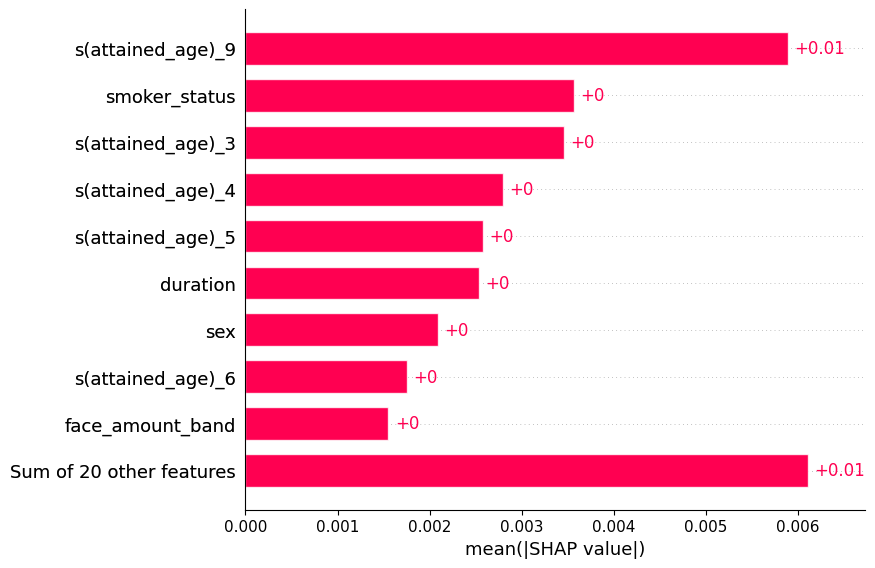

In [42]:
shap.plots.bar(Shap.shap_values)

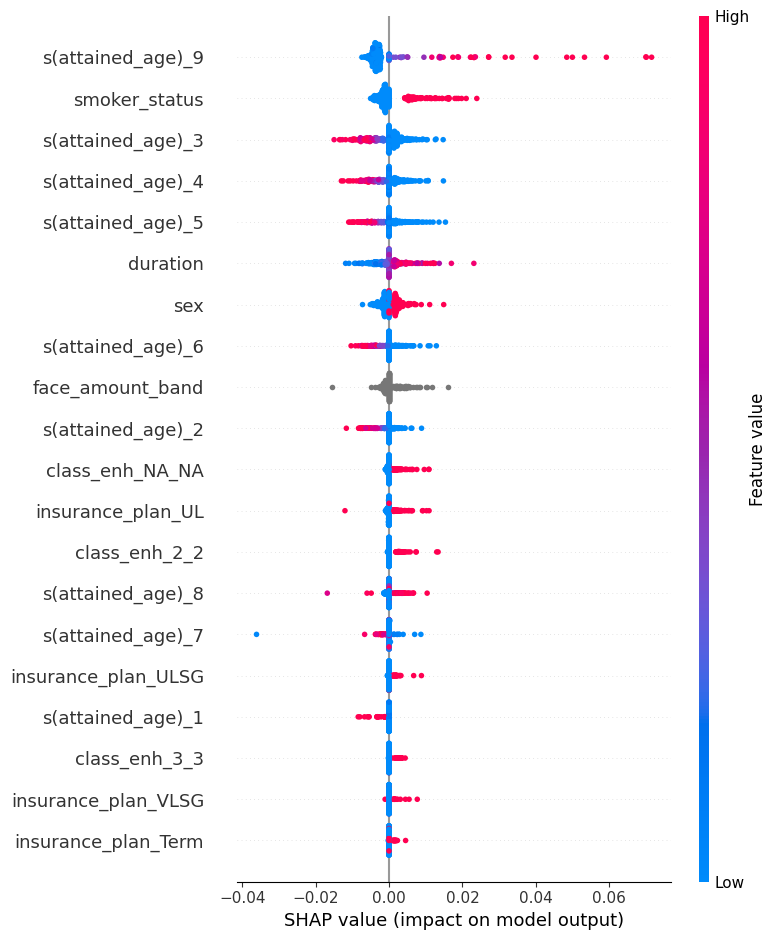

In [43]:
shap.summary_plot(Shap.shap_values, Shap.sample_explain_df)

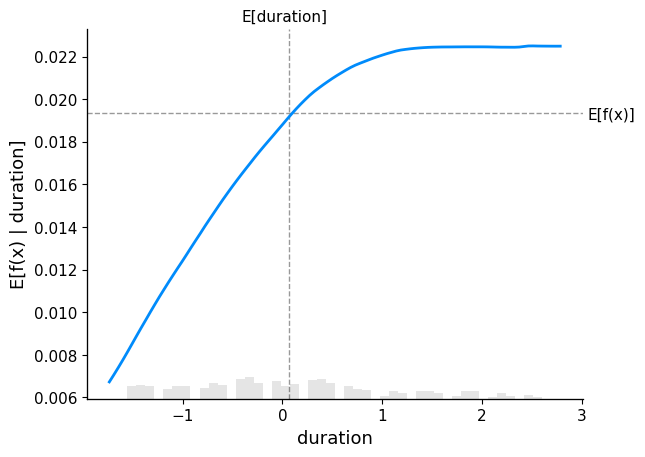

In [44]:
shap.partial_dependence_plot(
    "duration",
    model.predict,
    Shap.sample_explain_df,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
)

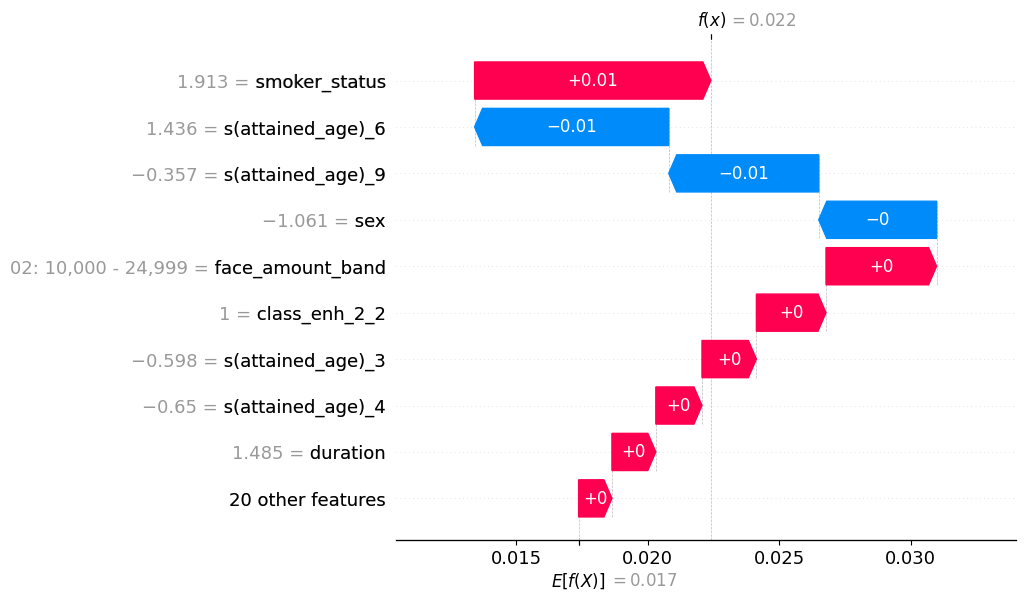

In [45]:
shap.plots.waterfall(Shap.shap_values[0])

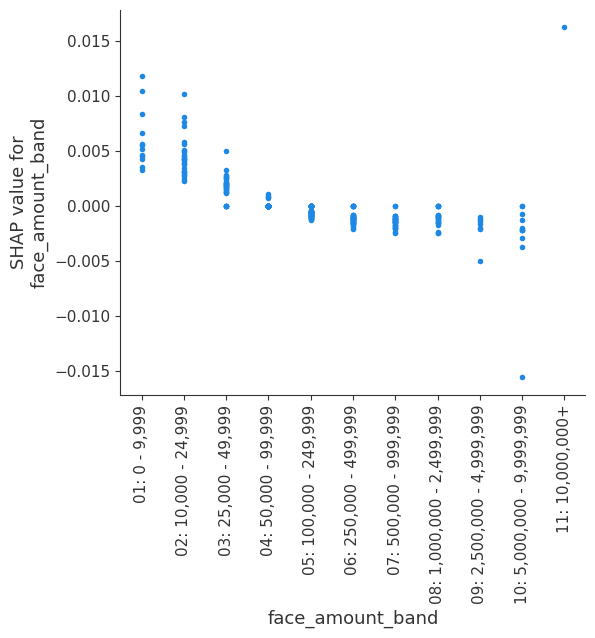

In [46]:
shap.dependence_plot(
    "face_amount_band",
    Shap.shap_values.values,
    Shap.sample_explain_df,
    interaction_index=None,
)

## Embedding Analysis

The column `face_amount_band` was embedded to have the neural network learn the relationships of this column naturally instead of using an encoding such as ordinal or nominal. To understand the embeddings better, the weights of the embeddings were extracted and then analyzed using cosine similarity, pca, or t-sne. As seen the embeddings are 6 dimensions.

In [47]:
model.embedding_get_weights("face_amount_band")

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5
__UNK__,0.13,-0.57,-0.12,-0.53,-0.40,-0.02
"05: 100,000 - 249,999",-0.08,-0.31,-0.37,-0.67,0.81,0.38
"06: 250,000 - 499,999",0.09,-0.44,-0.78,-0.42,0.70,-0.13
"04: 50,000 - 99,999",-0.29,-0.63,-0.48,-0.19,1.13,-0.14
"07: 500,000 - 999,999",0.06,-0.38,-0.73,-0.58,0.48,0.01
"01: 0 - 9,999",-0.64,-0.62,0.63,-0.41,1.03,0.70
"02: 10,000 - 24,999",-0.69,-0.79,0.09,-0.04,1.14,0.07
"11: 10,000,000+",0.78,-0.29,0.72,0.52,-0.53,0.75
"10: 5,000,000 - 9,999,999",-0.71,0.34,-0.65,1.01,0.15,0.28
"03: 25,000 - 49,999",-0.57,-0.51,0.19,-0.41,1.03,0.41


The relationships show that face amounts close to eachother are more similar to ones that are farther apart. The PCA analysis shows that the 5M+ face bands are the farthest apart from other face bands

In [48]:
model.embedding_plot_similarity("face_amount_band")

In [49]:
model.embedding_plot_2d("face_amount_band", method="pca")

In [52]:
model.embedding_plot_2d("face_amount_band", method="tsne")

In [50]:
charters.pdp(
    model=model,
    df=md_encoded[((md_encoded["duration"] <= 30))],
    x_axis="face_amount_band",
    weight="amount_exposed",
    mapping=mapping,
    display=True,
)

 2026-01-22 03:37:05 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2026-01-22 03:37:05 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2026-01-22 03:37:05 | morai.experience.charters | INFO     | x_axis: [face_amount_band] type: [passthrough] center: [global] 
 2026-01-22 03:37:06 | morai.experience.charters | INFO     | Creating 11 predictions. 


Processing:   0%|          | 0/11 [00:00<?, ?combo/s]

# Reload

In [ ]:
import importlib

In [ ]:
importlib.reload(neural)